In [1]:

from data_loader import DataLoader
from data_synthesizer.pipeline import  load_all_results

from evaluation_report.ressemblance_report import ResemblanceReport
from evaluation_report.utility_report import UtilityReport
from evaluation_report.privacy_report import PrivacyReport 
from evaluation_report.privacy_anonymeter_report import PrivacyAnonymeterReport


In [2]:
import sys
from pathlib import Path

# Add repo root so `import experiments` works in notebooks.
sys.path.append(str(Path.cwd().parent.parent))

from experiments.paths import DATA_DIR, BASELINE_DIR, UTILITY_ONLY_DIR, PRIVACY_ONLY_DIR


In [3]:
import numpy as np
import matplotlib.pyplot as plt

from experiments.pipeline_experiment.baseline_utils import (
    plot_per_feature_heatmap,
    plot_per_feature_heatmap_multi,
    plot_per_feature_bar_multi,
    get_cohen_result,
    get_jsdivergence_result,
    get_anonymeter_result,
    build_summary_df,
    plot_matrix_errors_vs_rankcorr,
    build_utility_long_meanstd,
    scatter_trtr_vs_tstr,
    bar_delta_tstr_trtr,
    multi_scatter_trtr_vs_tstr_meanstd,
    multi_scatter_trtr_vs_tstr,
    build_attr_clf_long,
    make_attr_clf_grid,
    build_attr_reg_long,
    make_attr_reg_grid,
    build_anonymeter_df,
    plot_anonymeter_summary,
    anonymeter_pretty_tables
)


## Loading Data

In [2]:
!git -C ../../pipeline_tabular_data_results lfs pull --include "privacy_evaluation_pipeline/*baseline*/*"

In [4]:
!git -C ../../pipeline_tabular_data_results lfs pull --include "data/**,baseline/**"
!git -C ../../pipeline_tabular_data_results lfs pull --include "utility_evaluation_pipeline/*baseline*/*"
!git -C ../../pipeline_tabular_data_results lfs pull --include "privacy_evaluation_pipeline/*baseline*/*"



In [ ]:
cat_list_credit_card = ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6', 'default.payment.next.month']
num_list_credit_card = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4','BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3','PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
credit_qai_columns = ['LIMIT_BAL','SEX','EDUCATION','MARRIAGE','AGE']
credit_risk_column = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6','BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6','PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6','default.payment.next.month']

df_real_credit_card_train = DataLoader(f'{DATA_DIR}/credit_card_Train.csv').get_dataframe(cat_list_credit_card,  drop_identation=True)
df_real_credit_card_test = DataLoader(f'{DATA_DIR}/credit_card_Test.csv').get_dataframe(cat_list_credit_card,  drop_identation=True)


In [6]:
cat_list_adult = ['workclass','education','marital-status','occupation','relationship','race','sex','native-country','income']
num_list_adult = ['age','fnlwgt','education-num','capital-gain','capital-loss','hours-per-week']
adult_qai_columns = ['education','education-num','marital-status','occupation','relationship','sex', 'native-country']
adult_risk_column = ['capital-gain','capital-loss','hours-per-week','income', 'race']
df_real_adult_train = DataLoader(f'{DATA_DIR}/adult_train.csv').get_dataframe(cat_list_adult)
df_real_adult_test = DataLoader(f'{DATA_DIR}/adult_test.csv').get_dataframe(cat_list_adult)


In [7]:
num_list_cardio = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']
cat_list_cardio = ['gender','cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']

cardio_qai_columns = ['age','gender','height','weight']
cardio_risk_column = ['ap_lo','ap_hi','cholesterol','gluc','smoke','alco','active','cardio']

df_real_cardio_train = DataLoader(f'{DATA_DIR}/cardio_train.csv').get_dataframe(cat_list_cardio, sep = ',')
df_real_cardio_test = DataLoader(f'{DATA_DIR}/cardio_test.csv').get_dataframe(cat_list_cardio, sep = ',')


In [8]:
credit_ctgan  = load_all_results(f'{BASELINE_DIR}/credit_ctgan_baseline')
credit_tvae  = load_all_results(f'{BASELINE_DIR}/credit_tvae_baseline')


dict_results_credit = {
    'credit CTGAN' : credit_ctgan,
    'credit TVAE' : credit_tvae}



/home/dayav/projects/temp/pipeline_synthetic_tabular_data/.pipeline/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning:

Trying to unpickle estimator BayesianGaussianMixture from version 1.3.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations

/home/dayav/projects/temp/pipeline_synthetic_tabular_data/.pipeline/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning:

Trying to unpickle estimator BayesianGaussianMixture from version 1.3.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations

/home/dayav/projects/temp/pipeline_synthetic_tabular_data/.pipeline/lib/python3.11/site-packages/sklearn/base.py

In [8]:
adult_ctgan  = load_all_results(f'{BASELINE_DIR}/adult_ctgan_baseline')
adult_tvae  = load_all_results(f'{BASELINE_DIR}/adult_tvae_baseline')

dict_results_adult  = {
    'adult CTGAN' : adult_ctgan,
    'adult TVAE' : adult_tvae}

/home/dayav/projects/temp/pipeline_synthetic_tabular_data/.baseline/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning:

Trying to unpickle estimator BayesianGaussianMixture from version 1.3.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations

/home/dayav/projects/temp/pipeline_synthetic_tabular_data/.baseline/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning:

Trying to unpickle estimator BayesianGaussianMixture from version 1.3.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations

/home/dayav/projects/temp/pipeline_synthetic_tabular_data/.baseline/lib/python3.11/site-packages/sklearn/base.py

In [9]:
cardio_ctgan = load_all_results(f'{BASELINE_DIR}/cardio_ctgan_baseline')
cardio_tvae = load_all_results(f'{BASELINE_DIR}/cardio_tvae_baseline')

dict_results_cardio = {
    'cardio CTGAN' : cardio_ctgan,
    'cardio TVAE' : cardio_tvae}


/home/dayav/projects/temp/pipeline_synthetic_tabular_data/.baseline/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning:

Trying to unpickle estimator BayesianGaussianMixture from version 1.3.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations

/home/dayav/projects/temp/pipeline_synthetic_tabular_data/.baseline/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning:

Trying to unpickle estimator BayesianGaussianMixture from version 1.3.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations

/home/dayav/projects/temp/pipeline_synthetic_tabular_data/.baseline/lib/python3.11/site-packages/sklearn/base.py

In [10]:
credit_resemblance_report = ResemblanceReport(df_real_credit_card_train, cat_list_credit_card, num_list_credit_card, dict_results_credit)
credit_utility_report = UtilityReport(df_real_credit_card_train, cat_list_credit_card, num_list_credit_card, dict_results_credit)
credit_privacy_report = PrivacyReport(df_real_credit_card_train, cat_list_credit_card, num_list_credit_card, dict_results_credit)
credit_privacy_anonymeter_report = PrivacyAnonymeterReport(df_real_credit_card_train, cat_list_credit_card, num_list_credit_card, dict_results_credit)

adult_resemblance_report = ResemblanceReport(df_real_adult_train, cat_list_adult, num_list_adult, dict_results_adult)
adult_utility_report = UtilityReport(df_real_adult_train, cat_list_adult, num_list_adult, dict_results_adult)
adult_privacy_report = PrivacyReport(df_real_adult_train, cat_list_adult, num_list_adult, dict_results_adult)
adult_privacy_anonymeter_report = PrivacyAnonymeterReport(df_real_adult_train, cat_list_adult, num_list_adult, dict_results_adult)

cardio_resemblance_report = ResemblanceReport(df_real_cardio_train, cat_list_cardio, num_list_cardio, dict_results_cardio)
cardio_utility_report = UtilityReport(df_real_cardio_train, cat_list_cardio, num_list_cardio, dict_results_cardio)
cardio_privacy_report = PrivacyReport(df_real_cardio_train, cat_list_cardio, num_list_cardio, dict_results_cardio)
cardio_privacy_anonymeter_report = PrivacyAnonymeterReport(df_real_cardio_train, cat_list_cardio, num_list_cardio, dict_results_cardio)


## Univariate evaluation

In [13]:
js_credit = get_jsdivergence_result(dict_results_credit)
cohen_credit = get_cohen_result(dict_results_credit)

js_adult = get_jsdivergence_result(dict_results_adult)
cohen_adult = get_cohen_result(dict_results_adult)

js_cardio = get_jsdivergence_result(dict_results_cardio)
cohen_cardio = get_cohen_result(dict_results_cardio)


In [32]:
js = js_credit |js_adult|js_cardio
cohen = cohen_credit|cohen_adult|cohen_cardio

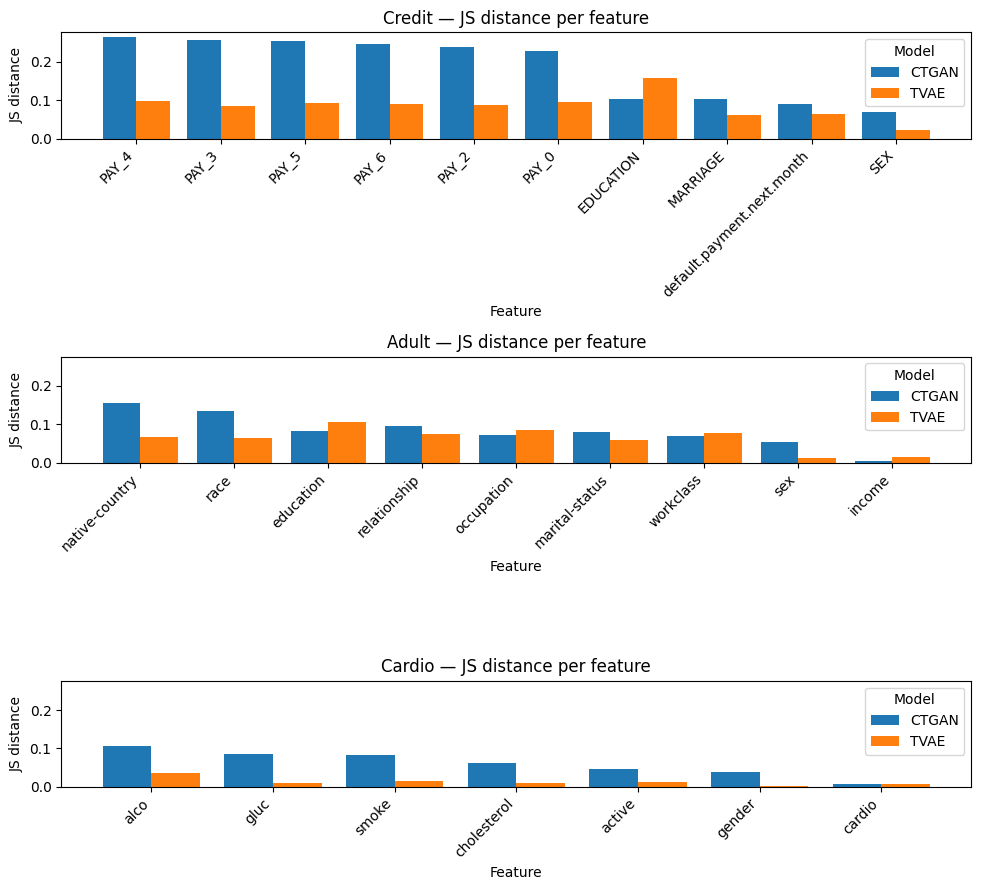

In [33]:
fig, axes = plot_per_feature_bar_multi(
    js,
    metric_name="JS distance",
    sort_features=True,
    datasets_order=["credit", "adult", "cardio"],
)
plt.show()


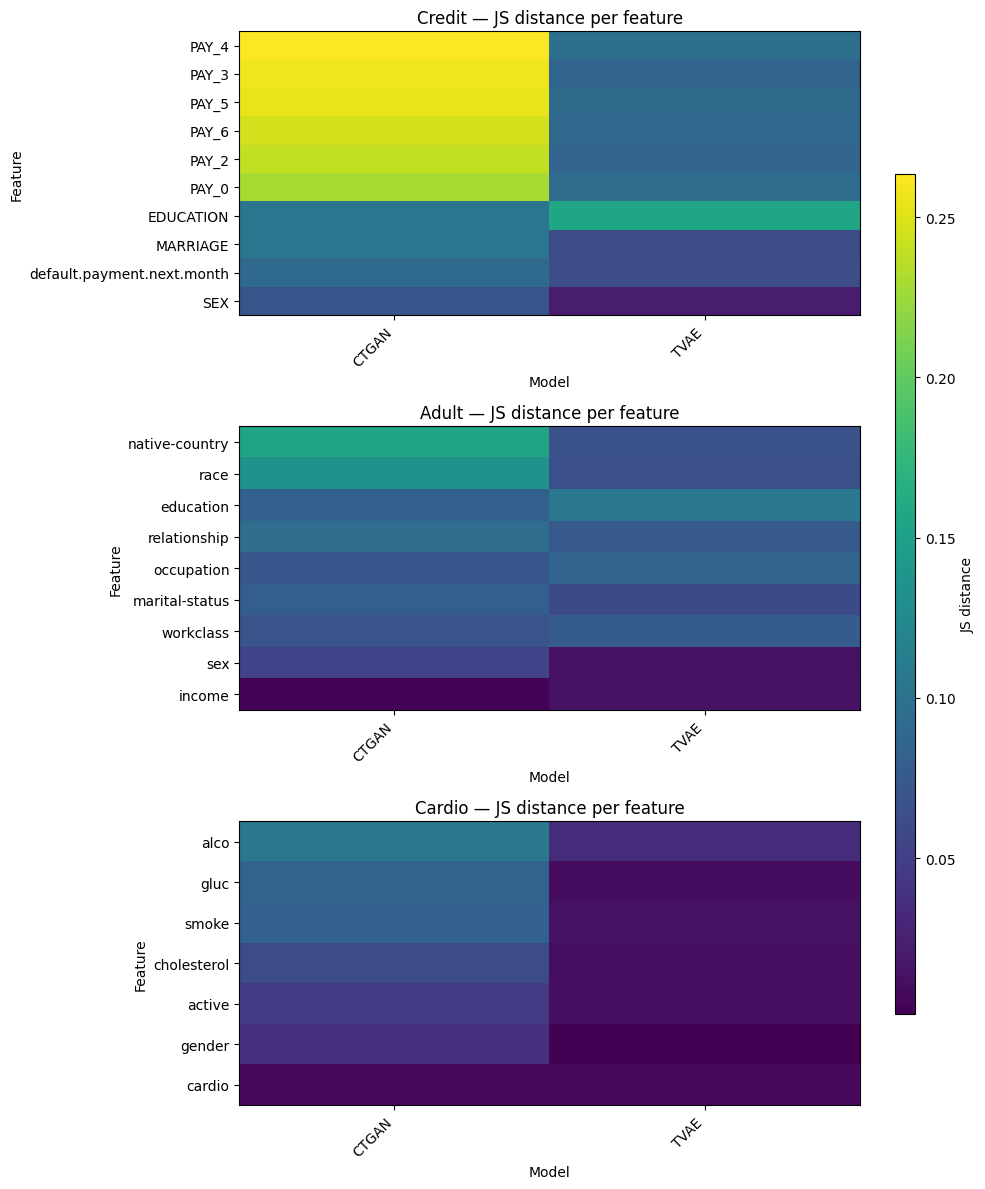

In [34]:

fig, axes = plot_per_feature_heatmap_multi(
    js,
    metric_name="JS distance",
    sort_features=True,
    # optional explicit ordering:
    datasets_order=["credit", "adult", "cardio"],
)
plt.show()


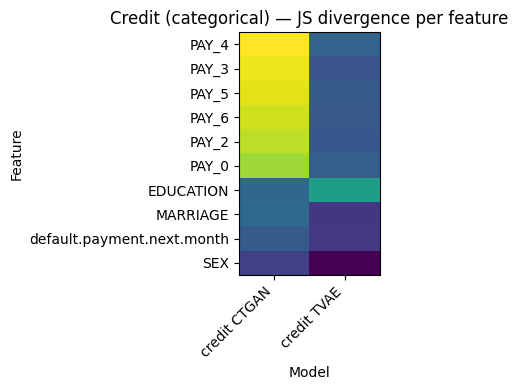

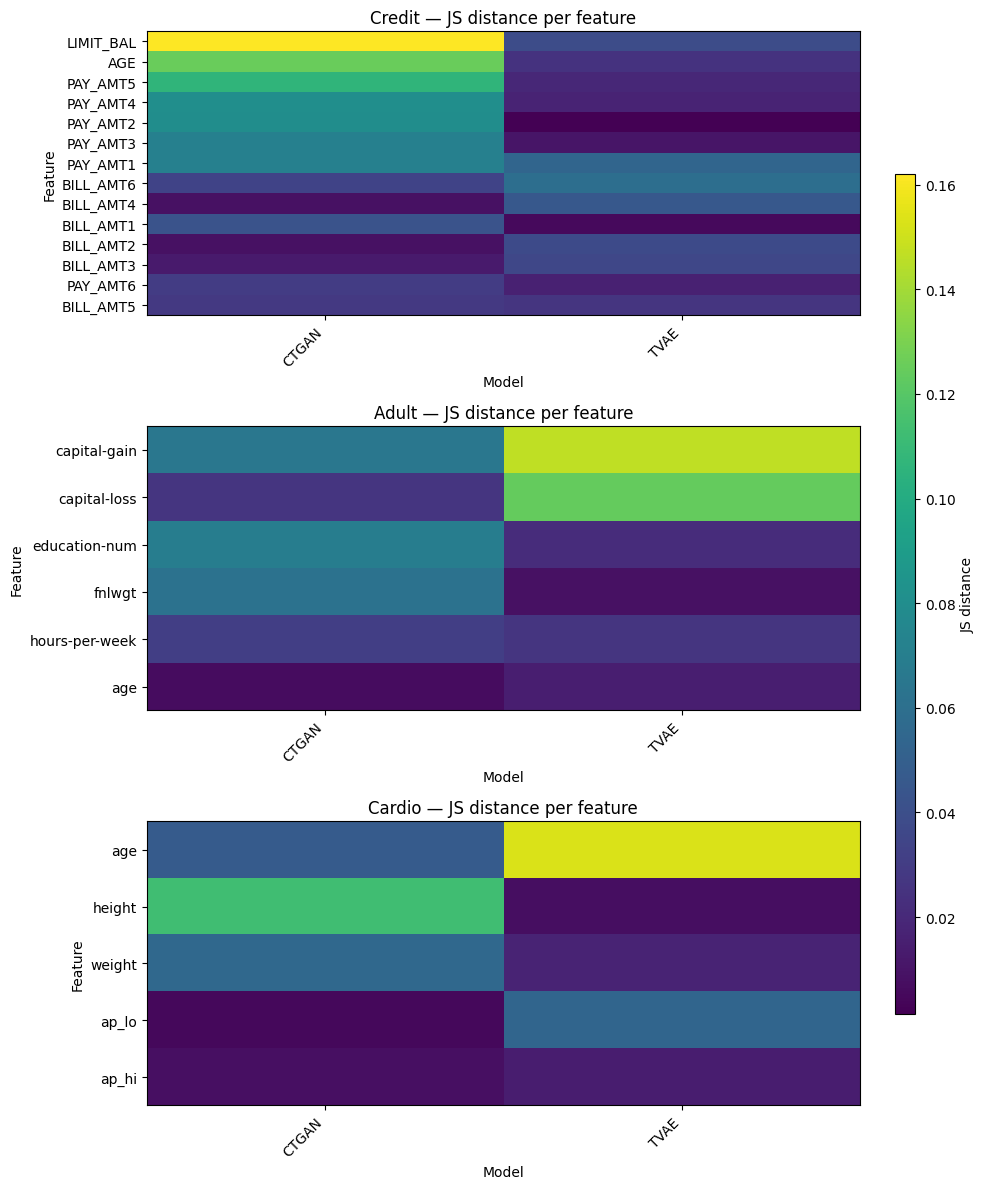

In [35]:
plot_per_feature_heatmap(
    js_credit,
    metric_name="JS divergence",
    dataset_name="Credit (categorical)"
)


fig, axes = plot_per_feature_heatmap_multi(
    cohen,
    metric_name="JS distance",
    sort_features=True,
    # optional explicit ordering:
    datasets_order=["credit", "adult", "cardio"],
)
plt.show()

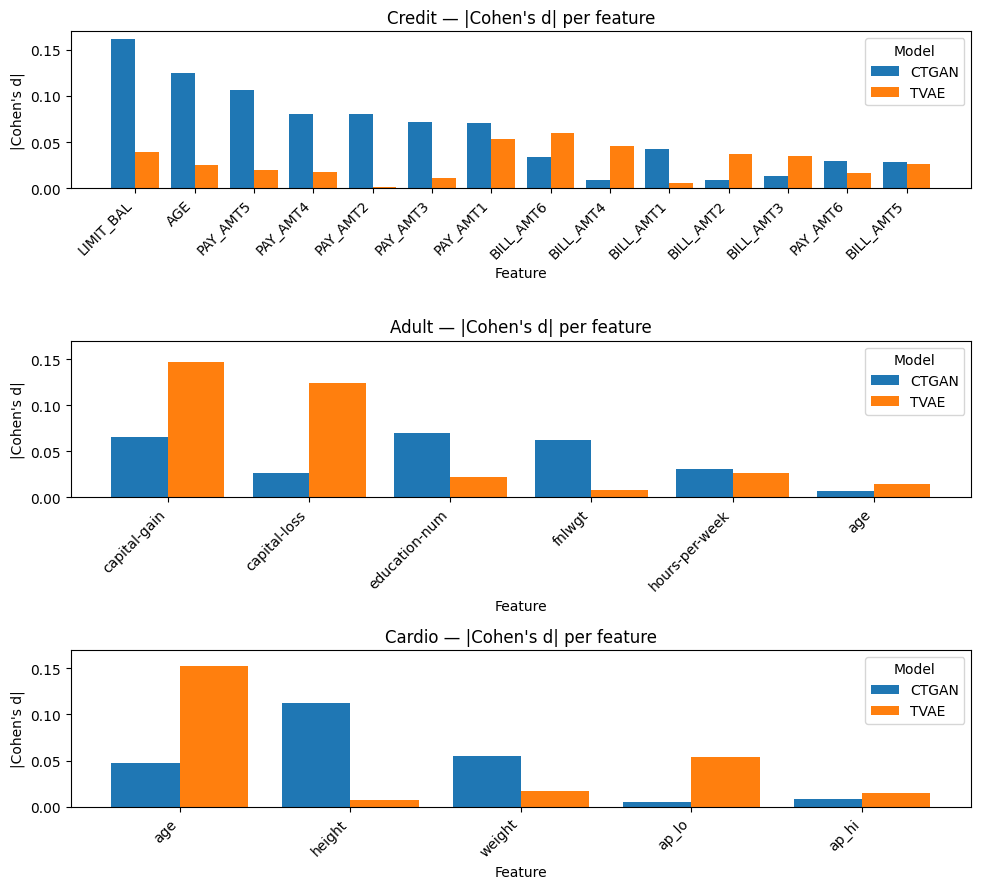

In [36]:
fig, axes = plot_per_feature_bar_multi(
    cohen,
    metric_name="|Cohen's d|",
    sort_features=True,
    datasets_order=["credit", "adult", "cardio"],
)
plt.show()


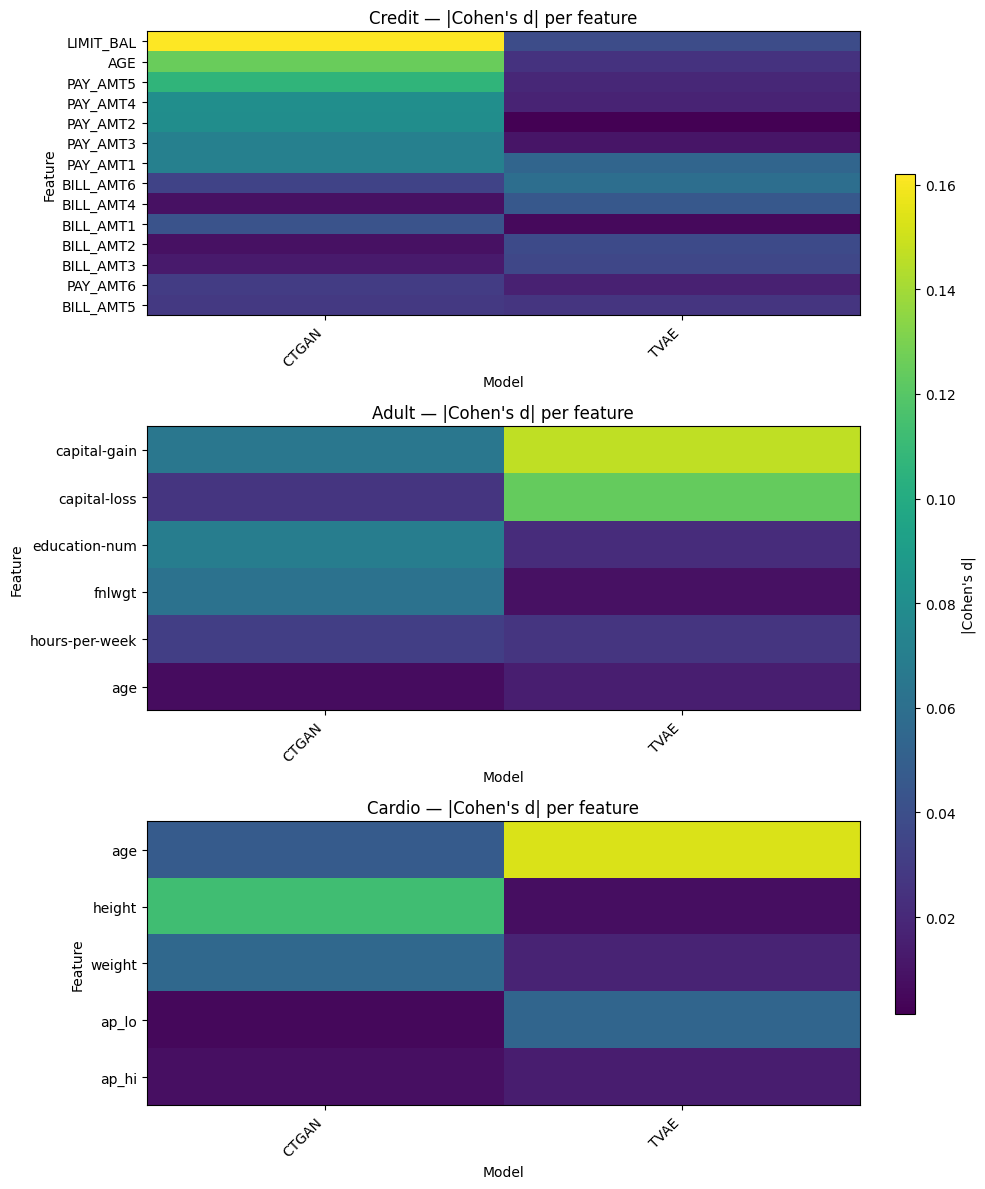

In [37]:
# plot_per_feature_heatmap(
#     cohen,
#     metric_name="|Cohen's d|",
#     dataset_name="Credit (numeric)"
# )

fig, axes = plot_per_feature_heatmap_multi(
    cohen,
    metric_name="|Cohen's d|",
    sort_features=True,
    # optional explicit ordering:
    datasets_order=["credit", "adult", "cardio"],
)
# plt.show()

## Multivariate Evaluation

In [38]:
corr_ratio = {}
pearson = {}
cramer = {}

for key, results in dict_results_credit.items() :
    corr_ratio[key] = results['resemblance_evaluation_results']['categorical_numerical_multivariate']
    pearson[key] = results['resemblance_evaluation_results']['numerical_multivariate']
    cramer[key] = results['resemblance_evaluation_results']['categorical_multivariate']


for key, results in dict_results_adult.items() :
    corr_ratio[key] = results['resemblance_evaluation_results']['categorical_numerical_multivariate']
    pearson[key] = results['resemblance_evaluation_results']['numerical_multivariate']
    cramer[key] = results['resemblance_evaluation_results']['categorical_multivariate']



for key, results in dict_results_cardio.items() :
    corr_ratio[key] = results['resemblance_evaluation_results']['categorical_numerical_multivariate']
    pearson[key] = results['resemblance_evaluation_results']['numerical_multivariate']
    cramer[key] = results['resemblance_evaluation_results']['categorical_multivariate']

In [39]:
summary_df = build_summary_df(
    corr_ratio,
    pearson,
    cramer
)
print(summary_df)

  dataset  model  diff_norm_corr_ratio  corr_ratio_spearman  \
0   adult  CTGAN                0.3561             0.910806   
1   adult   TVAE                0.4690             0.849133   
2  cardio  CTGAN                0.3699             0.834734   
3  cardio   TVAE                0.3473             0.728852   
4  credit  CTGAN                0.6158             0.936962   
5  credit   TVAE                0.7492             0.894260   

   pearson_norm_diff  pearson_spearman  diff_norm_cramer  cramer_spearman  
0             0.2148          0.810714            0.2967         0.913256  
1             0.2005          0.435714            0.4572         0.866152  
2             0.5061          0.418182            0.2621         0.810390  
3             0.2789          0.551515            0.2510         0.887013  
4             0.9750          0.793741            0.7986         0.940711  
5             0.8974          0.843319            1.0010         0.889196  


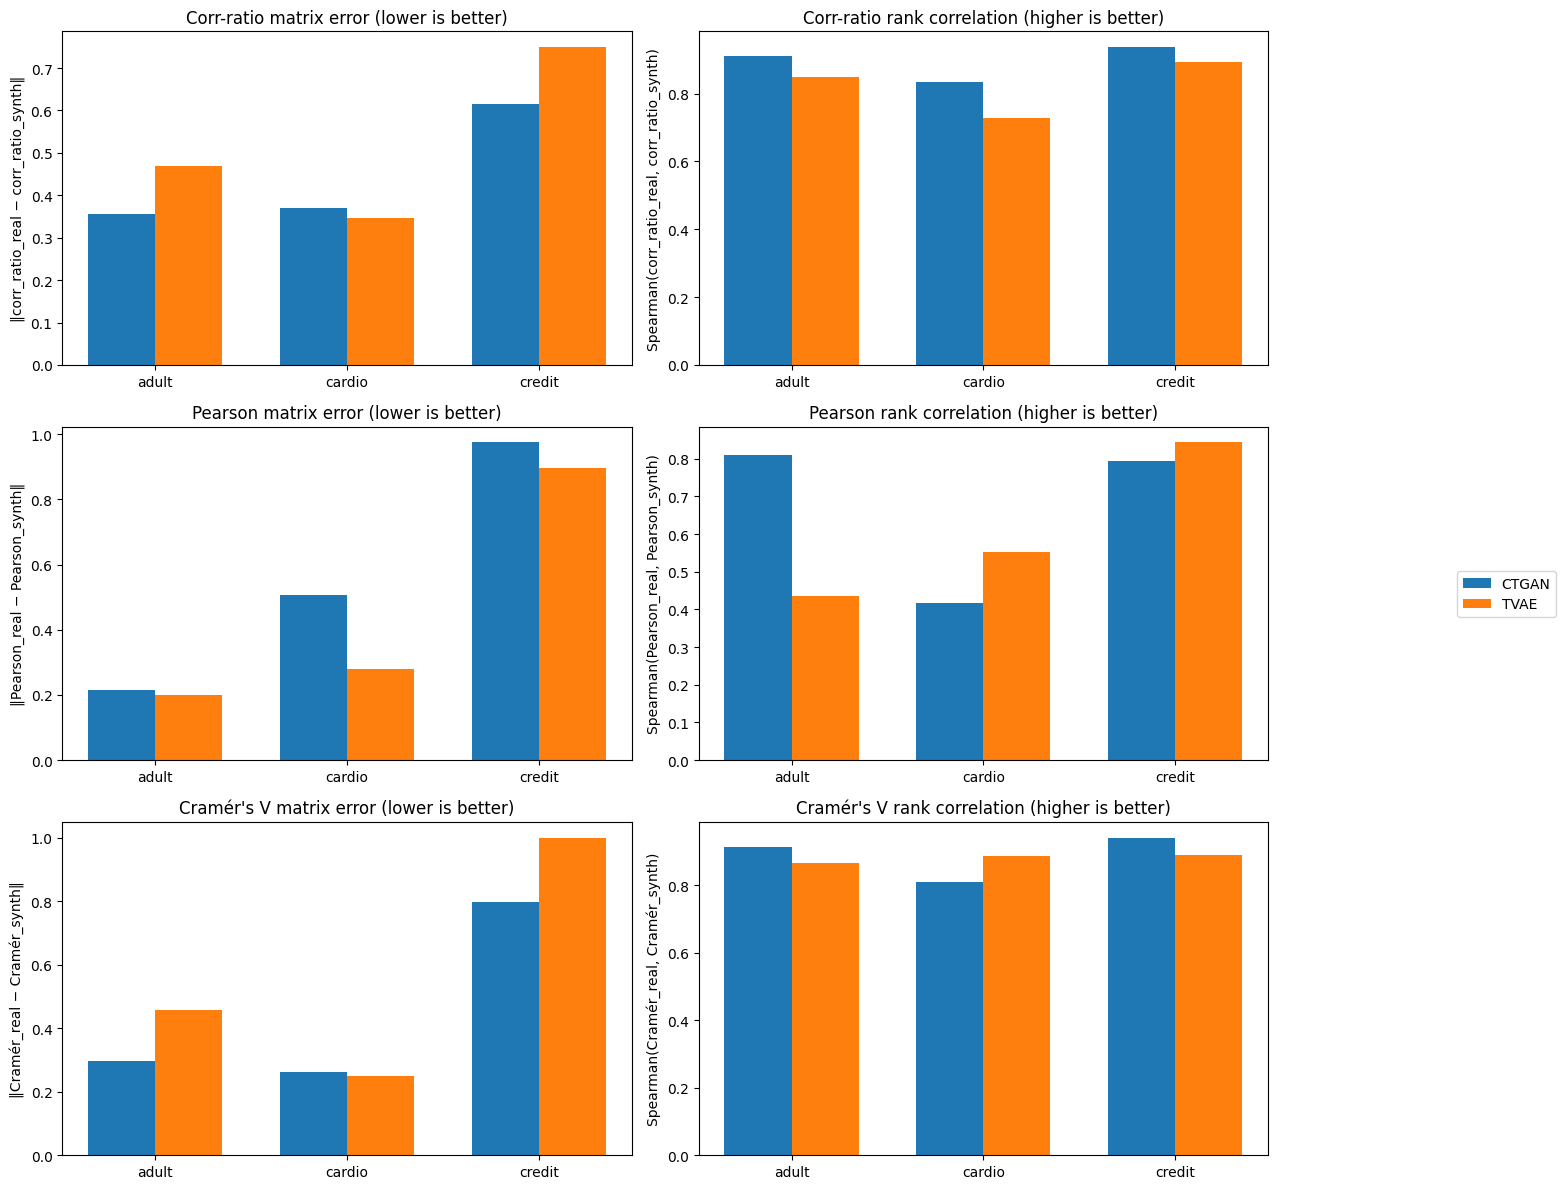

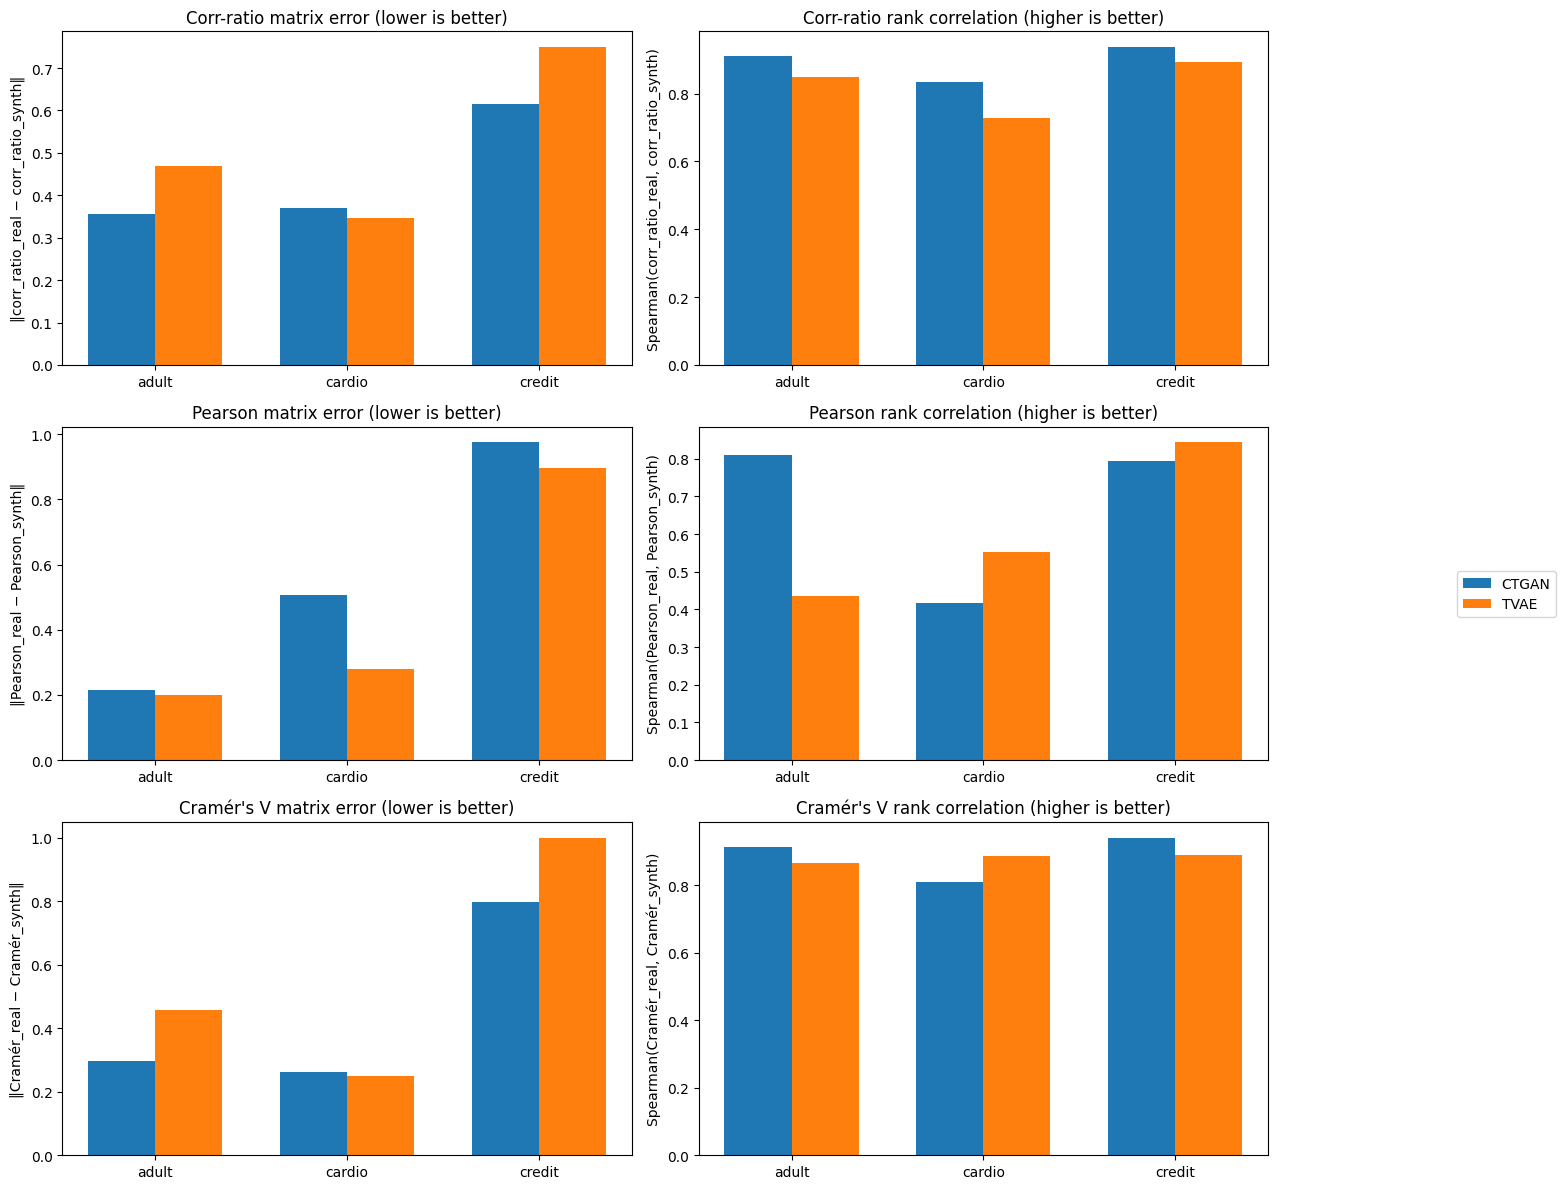

In [40]:
plot_matrix_errors_vs_rankcorr(summary_df)

## Utility evaluation

In [45]:
tstr_trtr = {}
credit_ctgan_utility = load_all_results(f'{UTILITY_ONLY_DIR}/credit_ctgan_baseline').to_legacy_dict()
credit_tvae_utility = load_all_results(f'{UTILITY_ONLY_DIR}/credit_tvae_baseline').to_legacy_dict()
adult_ctgan_utility = load_all_results(f'{UTILITY_ONLY_DIR}/adult_ctgan_baseline').to_legacy_dict()
adult_tvae_utility = load_all_results(f'{UTILITY_ONLY_DIR}/adult_tvae_baseline').to_legacy_dict()
cardio_ctgan_utility = load_all_results(f'{UTILITY_ONLY_DIR}/cardio_ctgan_baseline').to_legacy_dict()
cardio_tvae_utility = load_all_results(f'{UTILITY_ONLY_DIR}/cardio_tvae_baseline').to_legacy_dict()

tstr_trtr['credit_ctgan_trtr'] = credit_ctgan_utility['utility_evaluation_results']['train_real_test_real_results']
tstr_trtr['credit_ctgan_tstr'] = credit_ctgan_utility['utility_evaluation_results']['train_synthetic_test_real_results']

tstr_trtr['credit_tvae_trtr'] = credit_tvae_utility['utility_evaluation_results']['train_real_test_real_results']
tstr_trtr['credit_tvae_tstr'] = credit_tvae_utility['utility_evaluation_results']['train_synthetic_test_real_results']

tstr_trtr['adult_ctgan_trtr'] = adult_ctgan_utility['utility_evaluation_results']['train_real_test_real_results']
tstr_trtr['adult_ctgan_tstr'] = adult_ctgan_utility['utility_evaluation_results']['train_synthetic_test_real_results']

tstr_trtr['adult_tvae_trtr'] = adult_tvae_utility['utility_evaluation_results']['train_real_test_real_results']
tstr_trtr['adult_tvae_tstr'] = adult_tvae_utility['utility_evaluation_results']['train_synthetic_test_real_results']

tstr_trtr['cardio_ctgan_trtr'] = cardio_ctgan_utility['utility_evaluation_results']['train_real_test_real_results']
tstr_trtr['cardio_ctgan_tstr'] = cardio_ctgan_utility['utility_evaluation_results']['train_synthetic_test_real_results']

tstr_trtr['cardio_tvae_trtr'] = cardio_tvae_utility['utility_evaluation_results']['train_real_test_real_results']
tstr_trtr['cardio_tvae_tstr'] = cardio_tvae_utility['utility_evaluation_results']['train_synthetic_test_real_results']

In [61]:
 # Replace this with your actual dict name
utility_results = tstr_trtr
utility_long_meanstd = build_utility_long_meanstd(utility_results)
print(utility_long_meanstd)

     dataset  model regime classifier             metric      mean       std
0     credit  CTGAN   trtr       CART           accuracy  0.721167  0.002618
1     credit  CTGAN   trtr       CART      precision_avg  0.375323  0.004578
2     credit  CTGAN   trtr       CART         recall_avg  0.412567  0.004088
3     credit  CTGAN   trtr       CART             f1_avg  0.393055  0.003901
4     credit  CTGAN   trtr       CART  balanced_accuracy  0.610092  0.002666
...      ...    ...    ...        ...                ...       ...       ...
1531  cardio   TVAE   tstr    XGBoost            roc_auc  0.774715  0.000360
1532  cardio   TVAE   tstr    XGBoost      avg_precision  0.758038  0.000634
1533  cardio   TVAE   tstr    XGBoost                mcc  0.432555  0.001140
1534  cardio   TVAE   tstr    XGBoost        cohen_kappa  0.426750  0.001263
1535  cardio   TVAE   tstr    XGBoost           log_loss  0.576401  0.000254

[1536 rows x 7 columns]


In [54]:
utility_long = utility_long_meanstd.rename(columns={"mean": "value"})

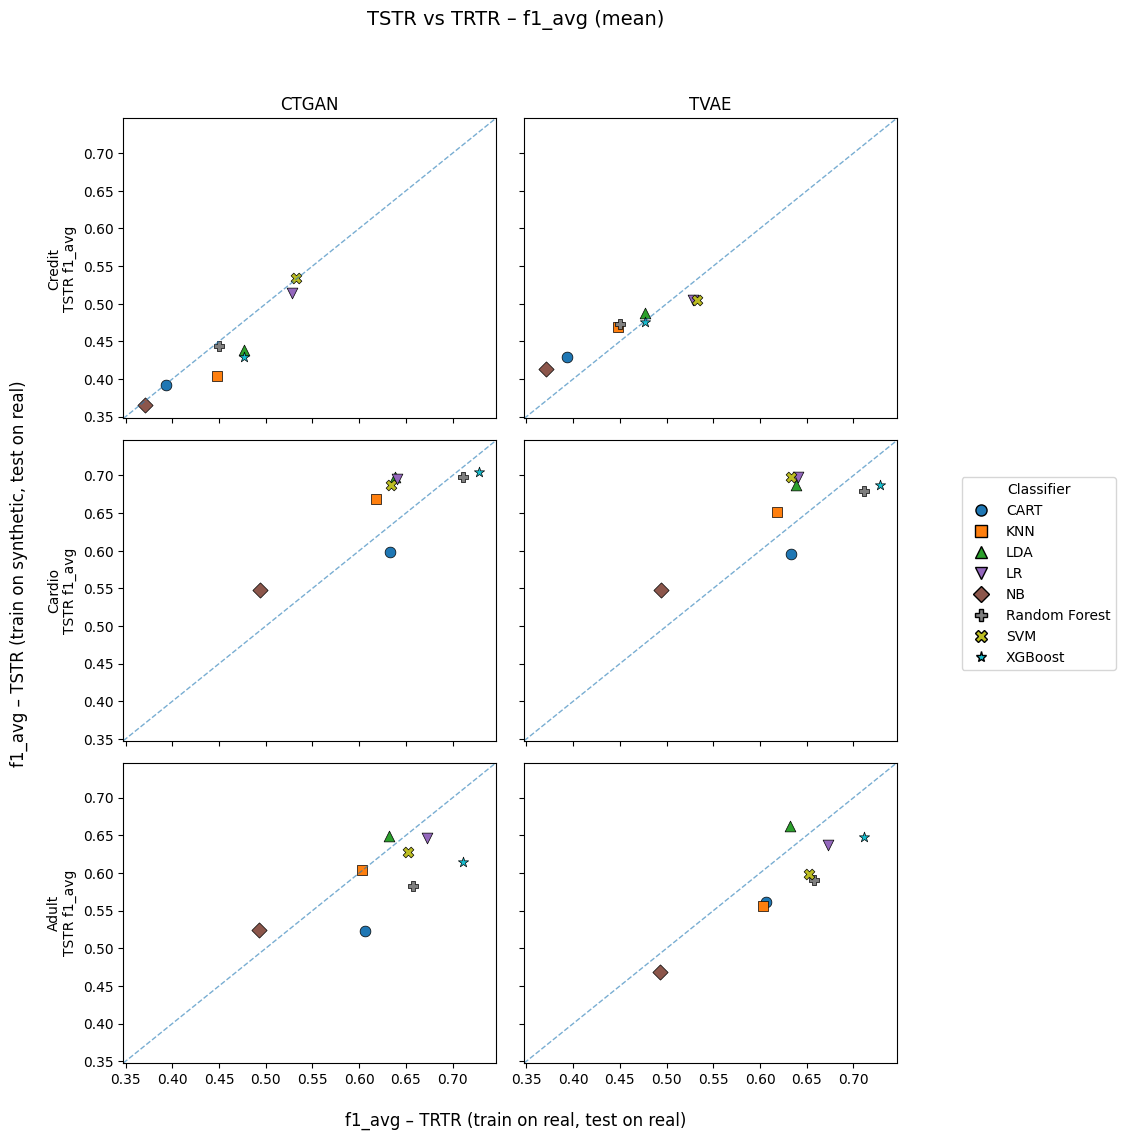

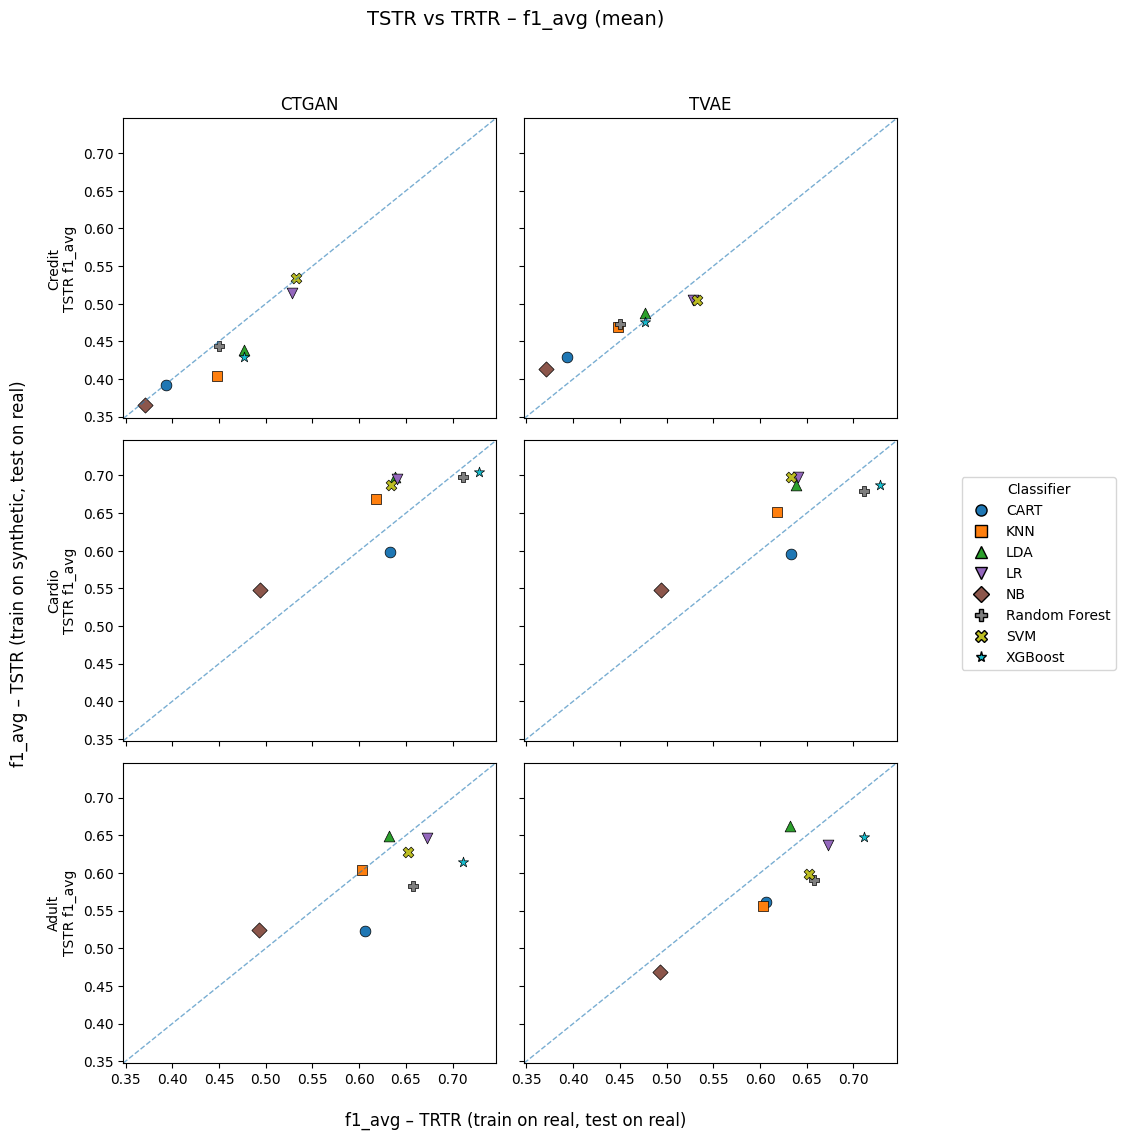

In [55]:
multi_scatter_trtr_vs_tstr_meanstd(utility_long_meanstd, "f1_avg")

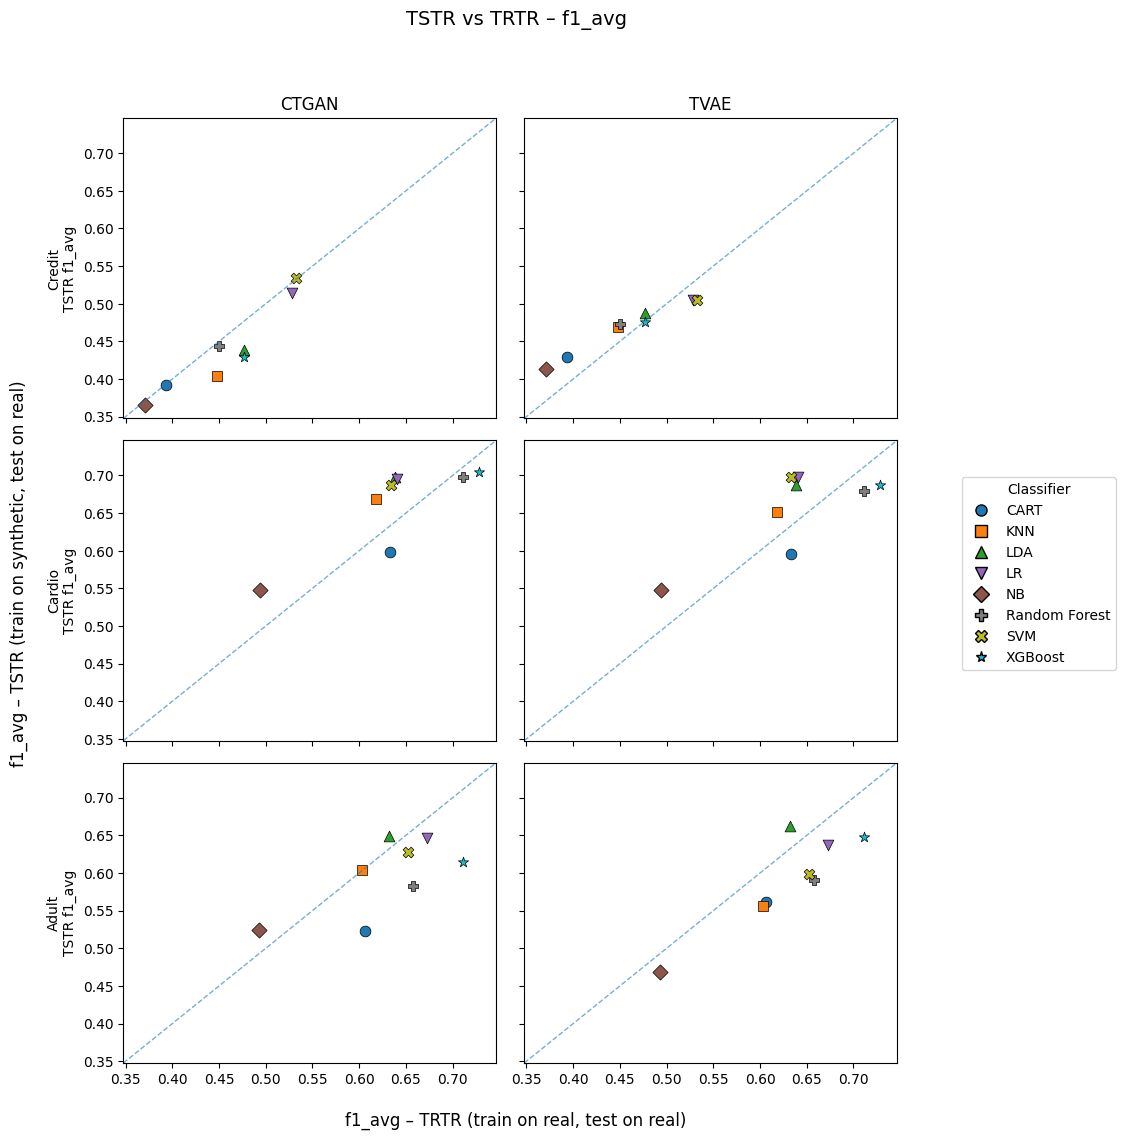

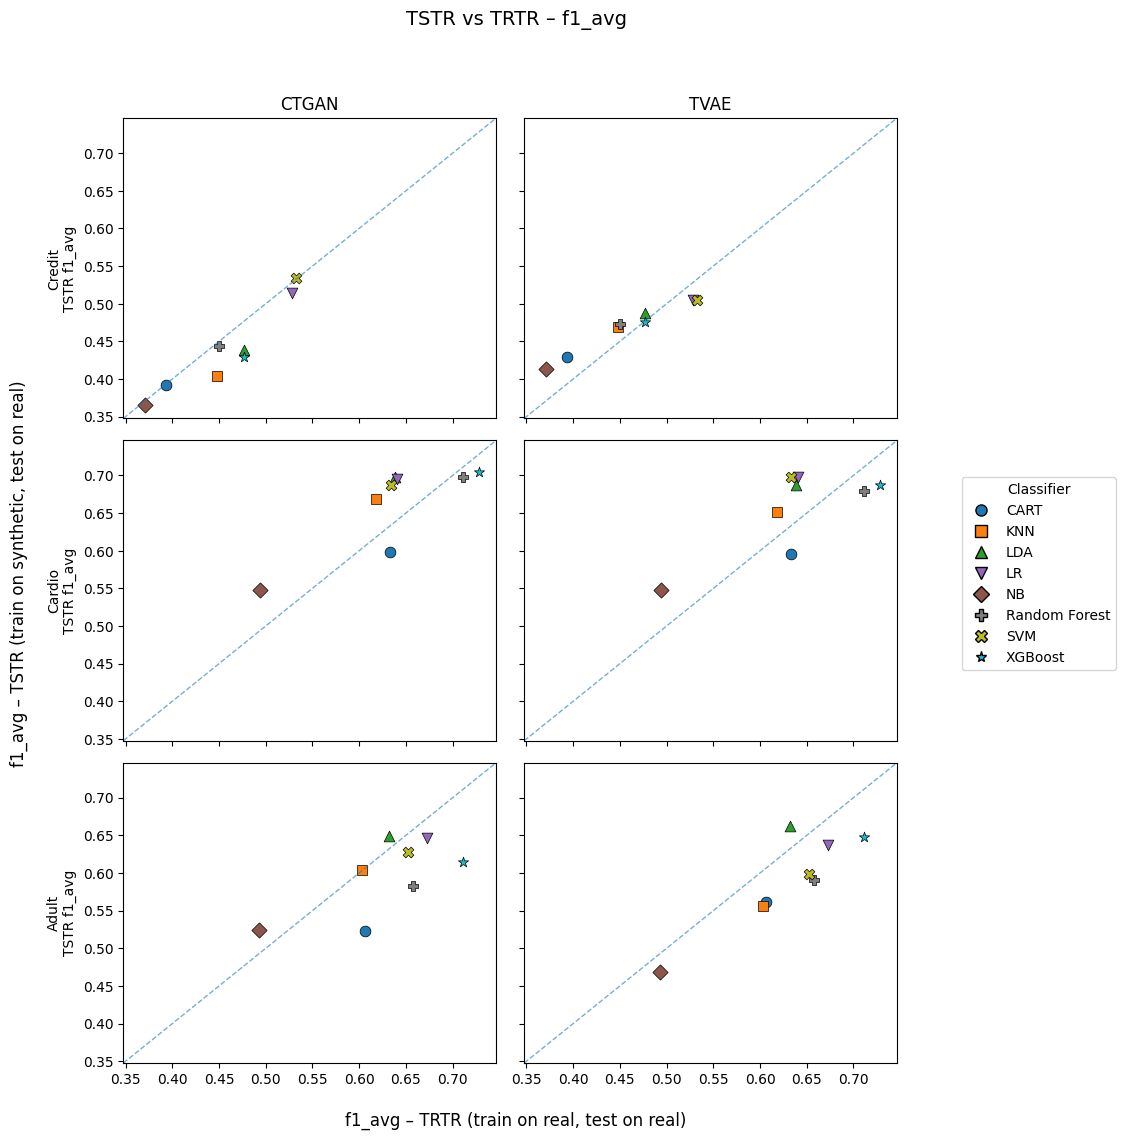

In [56]:
multi_scatter_trtr_vs_tstr(utility_long, "f1_avg")

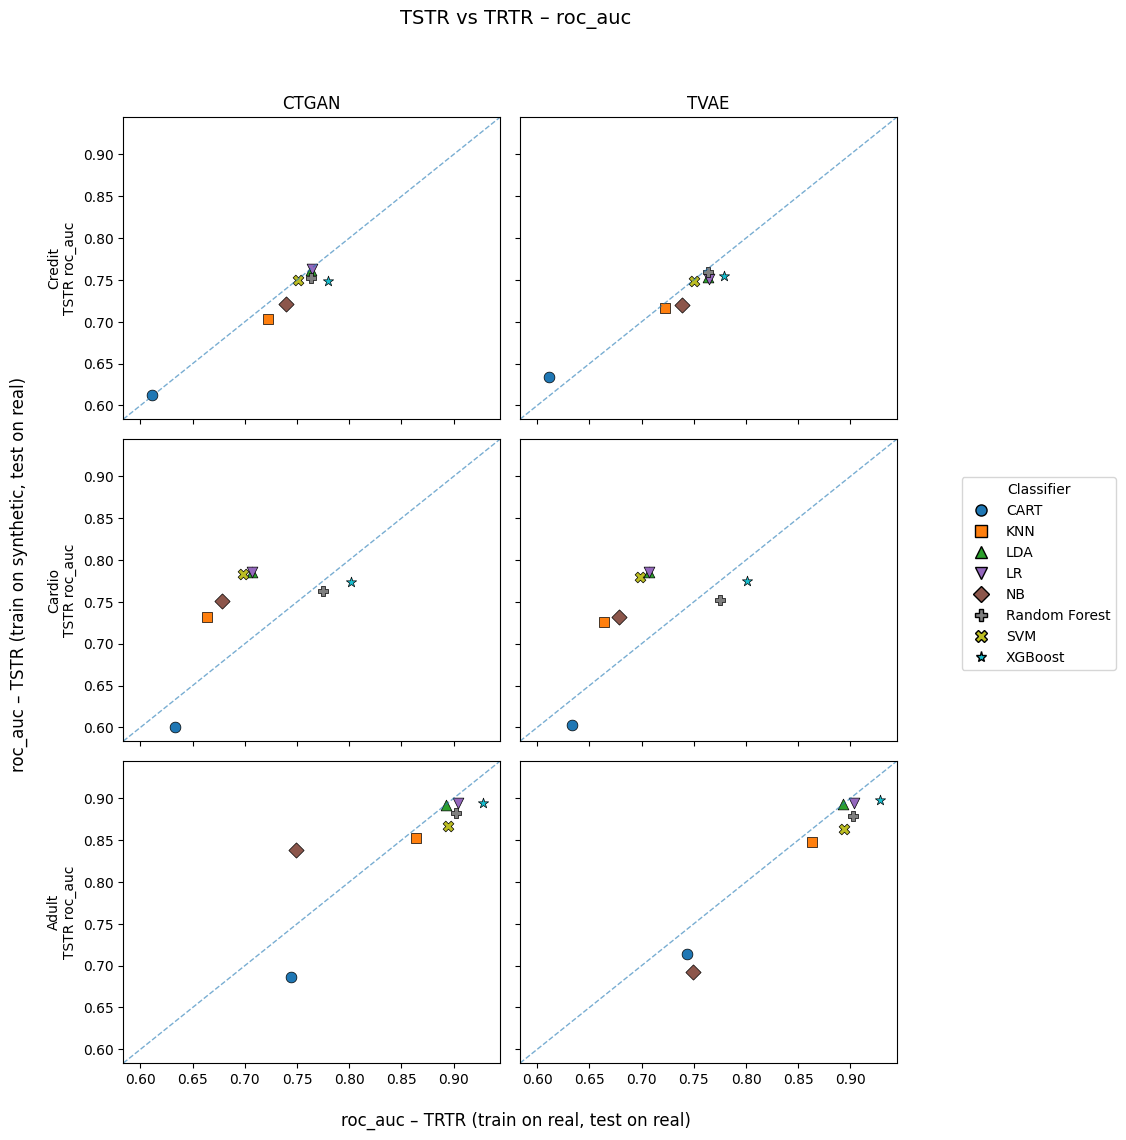

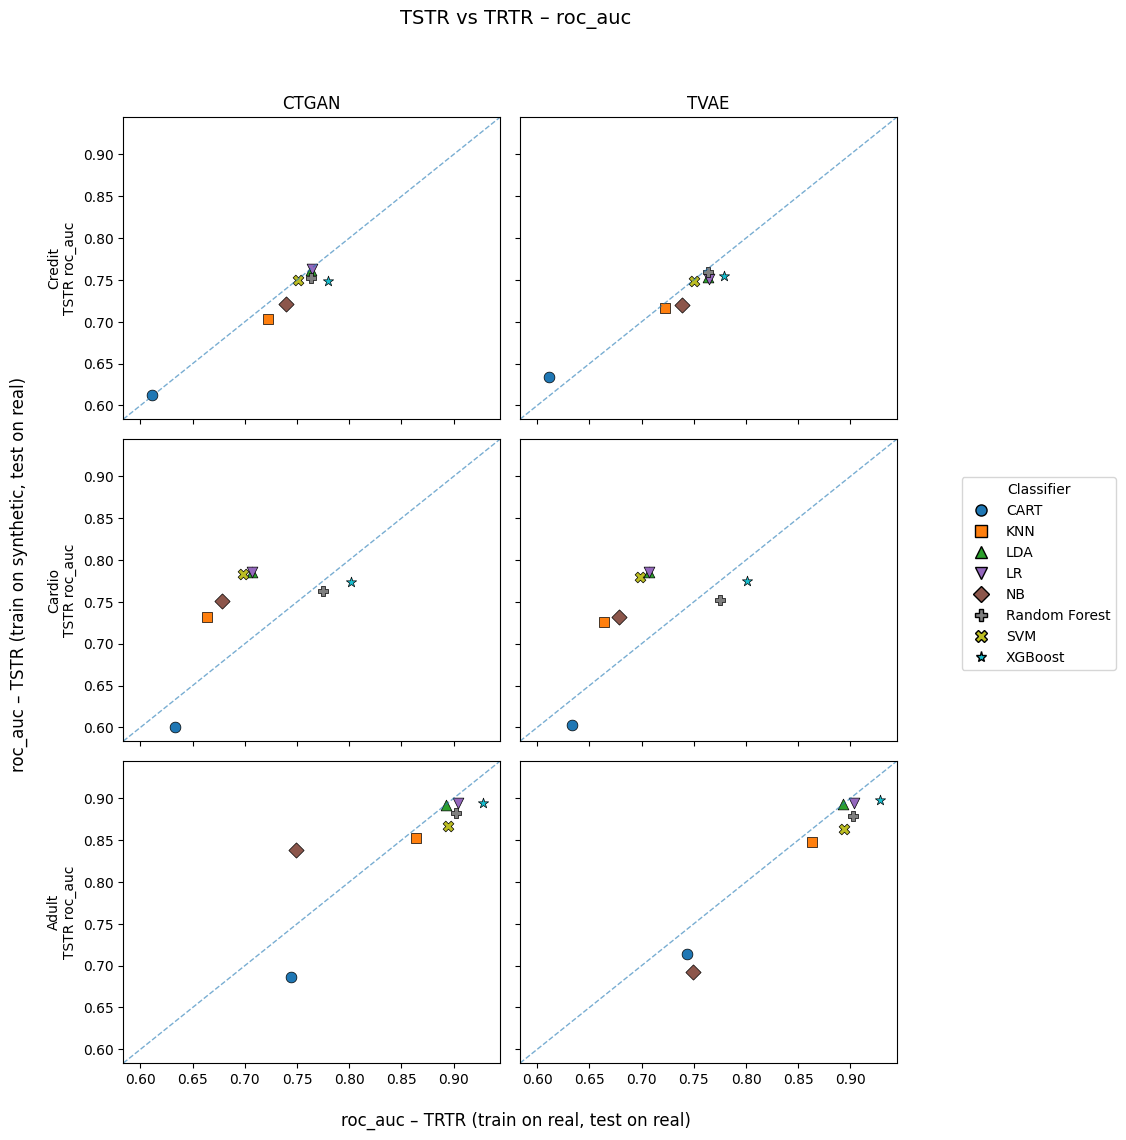

In [57]:
multi_scatter_trtr_vs_tstr(utility_long, "roc_auc")

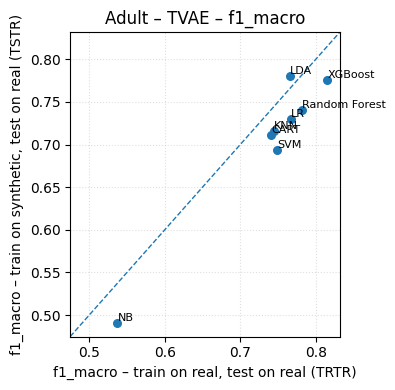

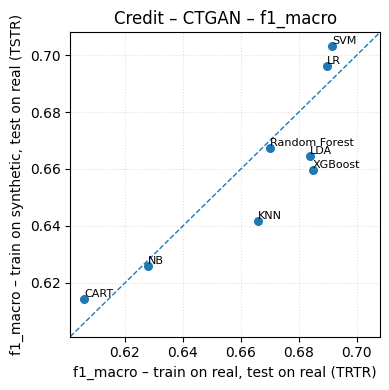

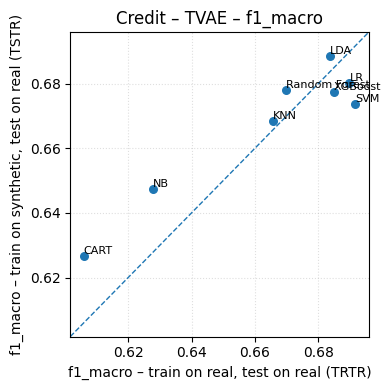

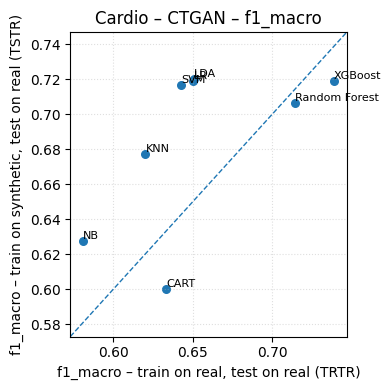

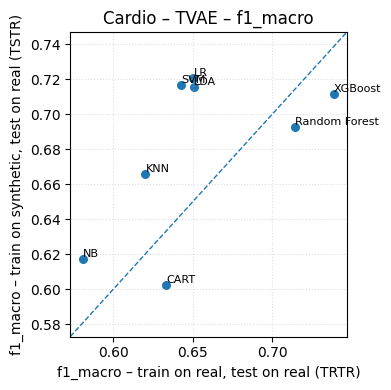

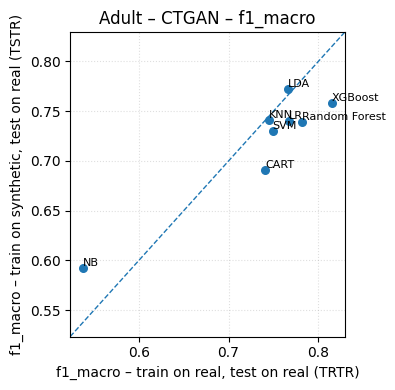

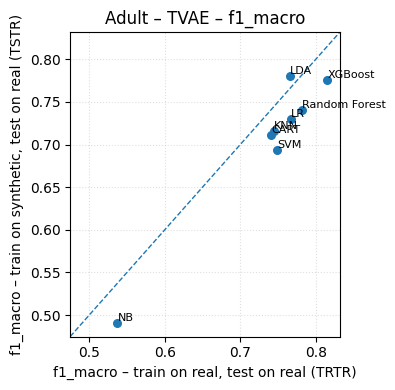

In [58]:
# CREDIT
scatter_trtr_vs_tstr(utility_long, "credit", "CTGAN", metric="f1_macro")
scatter_trtr_vs_tstr(utility_long, "credit", "TVAE",  metric="f1_macro")

# CARDIO
scatter_trtr_vs_tstr(utility_long, "cardio", "CTGAN", metric="f1_macro")
scatter_trtr_vs_tstr(utility_long, "cardio", "TVAE",  metric="f1_macro")

# ADULT
scatter_trtr_vs_tstr(utility_long, "adult", "CTGAN", metric="f1_macro")
scatter_trtr_vs_tstr(utility_long, "adult", "TVAE",  metric="f1_macro")


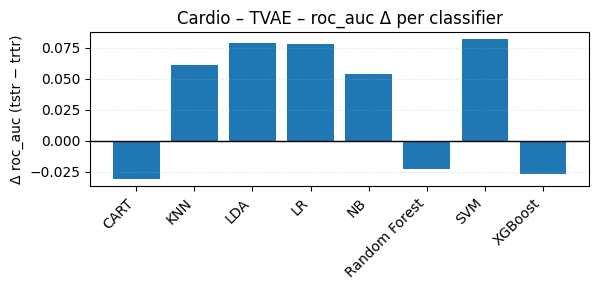

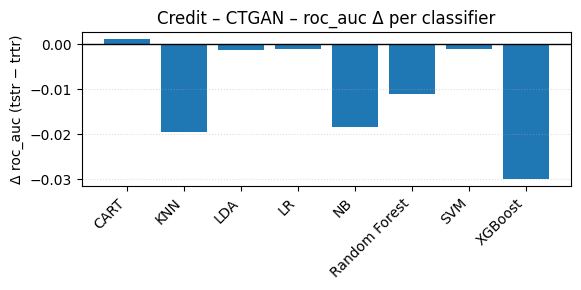

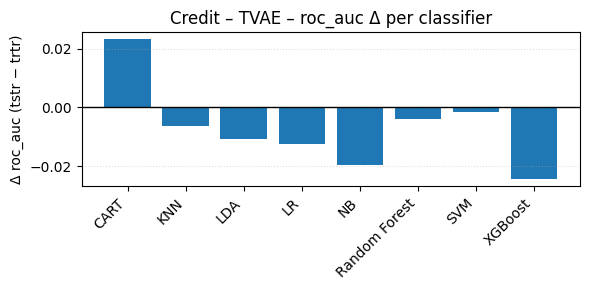

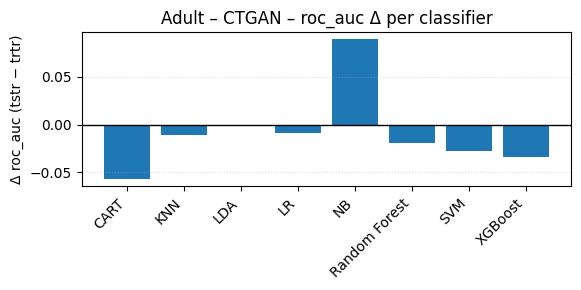

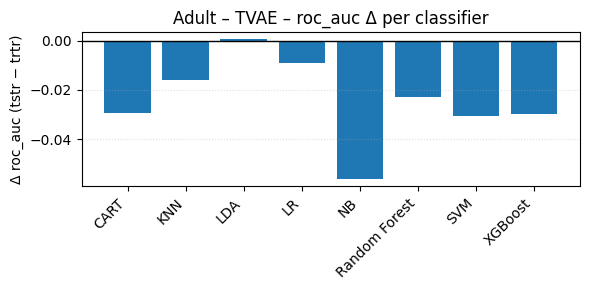

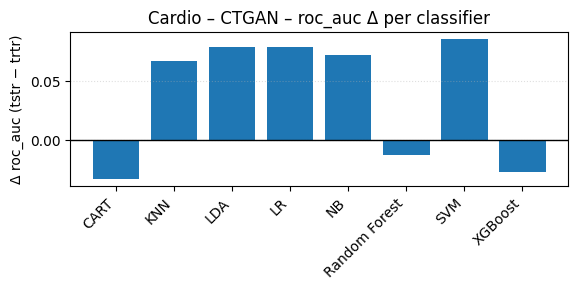

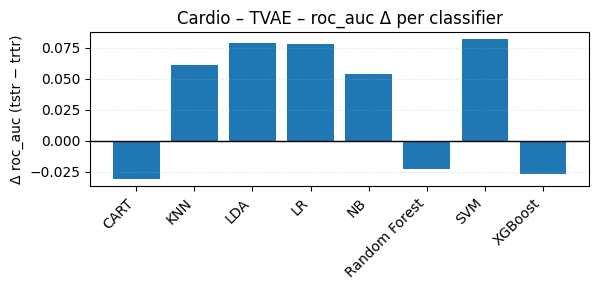

In [59]:
bar_delta_tstr_trtr(utility_long, "credit", "CTGAN", metric="roc_auc")
bar_delta_tstr_trtr(utility_long, "credit", "TVAE",  metric="roc_auc")
bar_delta_tstr_trtr(utility_long, "adult", "CTGAN", metric="roc_auc")
bar_delta_tstr_trtr(utility_long, "adult", "TVAE",  metric="roc_auc")
bar_delta_tstr_trtr(utility_long, "cardio", "CTGAN", metric="roc_auc")
bar_delta_tstr_trtr(utility_long, "cardio", "TVAE",  metric="roc_auc")


## Privacy Evaluation

In [25]:
result_classification_credit = {}
result_classification_adult = {}
result_classification_cardio = {}


result_classification_credit['credit_real_ctgan'] = load_all_results(f'{PRIVACY_ONLY_DIR}/credit_ctgan_baseline').privacy_evaluation_results.classification_results()['real']
result_classification_credit['credit_synth_ctgan'] = load_all_results(f'{PRIVACY_ONLY_DIR}/credit_ctgan_baseline').privacy_evaluation_results.classification_results()['synthetic']
result_classification_credit['credit_real_tvae'] = load_all_results(f'{PRIVACY_ONLY_DIR}/credit_tvae_baseline').privacy_evaluation_results.classification_results()['real']
result_classification_credit['credit_synth_tvae'] = load_all_results(f'{PRIVACY_ONLY_DIR}/credit_tvae_baseline').privacy_evaluation_results.classification_results()['synthetic']

result_classification_adult['adult_real_ctgan'] = load_all_results(f'{PRIVACY_ONLY_DIR}/adult_ctgan_baseline').privacy_evaluation_results.classification_results()['real']
result_classification_adult['adult_synth_ctgan'] = load_all_results(f'{PRIVACY_ONLY_DIR}/adult_ctgan_baseline').privacy_evaluation_results.classification_results()['synthetic']
result_classification_adult['adult_real_tvae'] = load_all_results(f'{PRIVACY_ONLY_DIR}/adult_tvae_baseline').privacy_evaluation_results.classification_results()['real']
result_classification_adult['adult_synth_tvae'] = load_all_results(f'{PRIVACY_ONLY_DIR}/adult_tvae_baseline').privacy_evaluation_results.classification_results()['synthetic']

result_classification_cardio['cardio_real_ctgan'] = load_all_results(f'{PRIVACY_ONLY_DIR}/cardio_ctgan_baseline').privacy_evaluation_results.classification_results()['real']
result_classification_cardio['cardio_synth_ctgan'] = load_all_results(f'{PRIVACY_ONLY_DIR}/cardio_ctgan_baseline').privacy_evaluation_results.classification_results()['synthetic']
result_classification_cardio['cardio_real_tvae'] = load_all_results(f'{PRIVACY_ONLY_DIR}/cardio_tvae_baseline').privacy_evaluation_results.classification_results()['real']
result_classification_cardio['cardio_synth_tvae'] = load_all_results(f'{PRIVACY_ONLY_DIR}/cardio_tvae_baseline').privacy_evaluation_results.classification_results()['synthetic']


result_regression_credit = {}
result_regression_adult = {}
result_regression_cardio = {}


result_regression_credit['credit_real_ctgan'] = load_all_results(f'{PRIVACY_ONLY_DIR}/credit_ctgan_baseline').privacy_evaluation_results.regression_results()['real']
result_regression_credit['credit_synth_ctgan'] = load_all_results(f'{PRIVACY_ONLY_DIR}/credit_ctgan_baseline').privacy_evaluation_results.regression_results()['synthetic']
result_regression_credit['credit_real_tvae'] = load_all_results(f'{PRIVACY_ONLY_DIR}/credit_tvae_baseline').privacy_evaluation_results.regression_results()['real']
result_regression_credit['credit_synth_tvae'] = load_all_results(f'{PRIVACY_ONLY_DIR}/credit_tvae_baseline').privacy_evaluation_results.regression_results()['synthetic']

result_regression_adult['adult_real_ctgan'] = load_all_results(f'{PRIVACY_ONLY_DIR}/adult_ctgan_baseline').privacy_evaluation_results.regression_results()['real']
result_regression_adult['adult_synth_ctgan'] = load_all_results(f'{PRIVACY_ONLY_DIR}/adult_ctgan_baseline').privacy_evaluation_results.regression_results()['synthetic']
result_regression_adult['adult_real_tvae'] = load_all_results(f'{PRIVACY_ONLY_DIR}/adult_tvae_baseline').privacy_evaluation_results.regression_results()['real']
result_regression_adult['adult_synth_tvae'] = load_all_results(f'{PRIVACY_ONLY_DIR}/adult_tvae_baseline').privacy_evaluation_results.regression_results()['synthetic']

result_regression_cardio['cardio_real_ctgan'] = load_all_results(f'{PRIVACY_ONLY_DIR}/cardio_ctgan_baseline').privacy_evaluation_results.regression_results()['real']
result_regression_cardio['cardio_synth_ctgan'] = load_all_results(f'{PRIVACY_ONLY_DIR}/cardio_ctgan_baseline').privacy_evaluation_results.regression_results()['synthetic']
result_regression_cardio['cardio_real_tvae'] = load_all_results(f'{PRIVACY_ONLY_DIR}/cardio_tvae_baseline').privacy_evaluation_results.regression_results()['real']
result_regression_cardio['cardio_synth_tvae'] = load_all_results(f'{PRIVACY_ONLY_DIR}/cardio_tvae_baseline').privacy_evaluation_results.regression_results()['synthetic']



In [37]:
result_classification = result_classification_credit |result_classification_adult | result_classification_cardio
attr_clf_long = build_attr_clf_long(result_classification)
attr_clf_long = attr_clf_long[attr_clf_long["attribute"] != "default.payment.next.month"]
attr_clf_long

,dataset,model,data_type,attribute,balanced_accuracy,macro_f1,accuracy
0,credit,CTGAN,real,PAY_0,0.108263,0.085963,0.491833
1,credit,CTGAN,real,PAY_2,0.120395,0.100586,0.524333
2,credit,CTGAN,real,PAY_3,0.097996,0.081612,0.519500
3,credit,CTGAN,real,PAY_4,0.104529,0.085491,0.535833
4,credit,CTGAN,real,PAY_5,0.113979,0.090138,0.553000
5,credit,CTGAN,real,PAY_6,0.113477,0.087214,0.542833
7,credit,CTGAN,synth,PAY_0,0.110735,0.092236,0.443167
8,credit,CTGAN,synth,PAY_2,0.122487,0.118631,0.451833
9,credit,CTGAN,synth,PAY_3,0.099126,0.093816,0.470667
10,credit,CTGAN,synth,PAY_4,0.104490,0.080071,0.525333


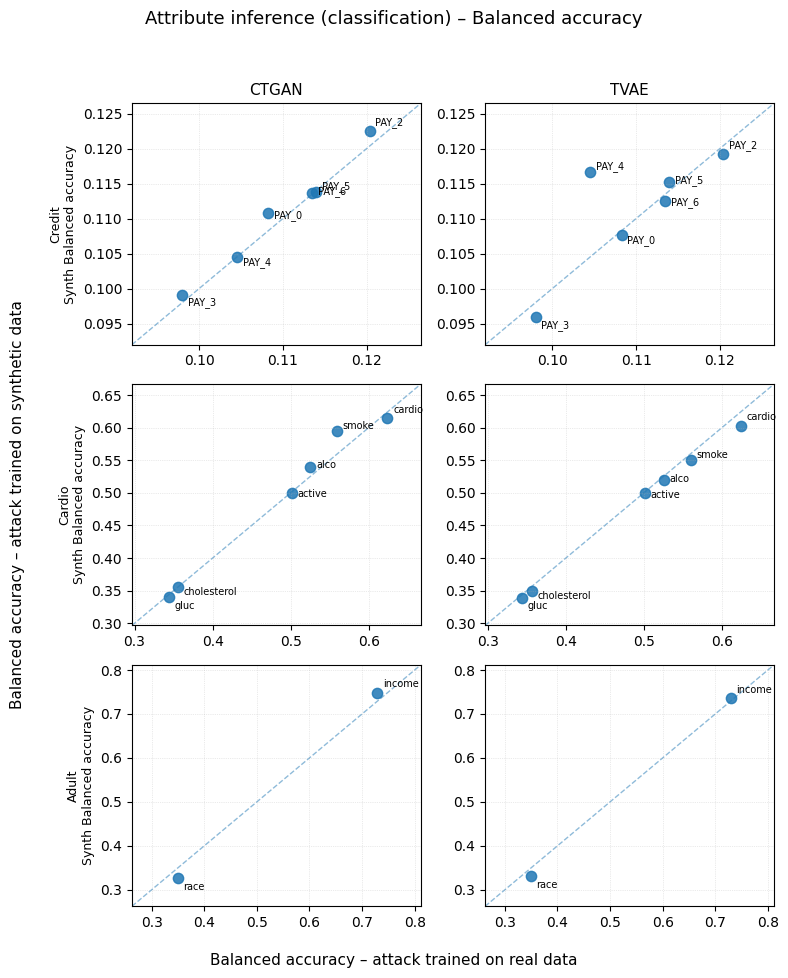

In [38]:
fig_ba = make_attr_clf_grid(attr_clf_long, metric="balanced_accuracy")

In [42]:
result_regression = result_regression_credit |result_regression_adult | result_regression_cardio
attr_reg_long = build_attr_reg_long(result_regression)
attr_reg_long

,dataset,model,data_type,attribute,mse,rmse,r2
0,credit,CTGAN,real,BILL_AMT1,5.468560e+09,73949.715757,0.016218
1,credit,CTGAN,real,BILL_AMT2,5.132743e+09,71643.165319,0.014177
2,credit,CTGAN,real,BILL_AMT3,4.788067e+09,69195.857598,0.013742
3,credit,CTGAN,real,BILL_AMT4,4.218446e+09,64949.562203,0.012705
4,credit,CTGAN,real,BILL_AMT5,3.731757e+09,61088.108722,0.011221
...,...,...,...,...,...,...,...
67,cardio,CTGAN,synth,ap_lo,2.928017e+04,171.114504,0.001020
68,cardio,TVAE,real,ap_hi,2.060347e+04,143.539073,0.001086
69,cardio,TVAE,real,ap_lo,2.926750e+04,171.077466,0.001452
70,cardio,TVAE,synth,ap_hi,2.060945e+04,143.559913,0.000796


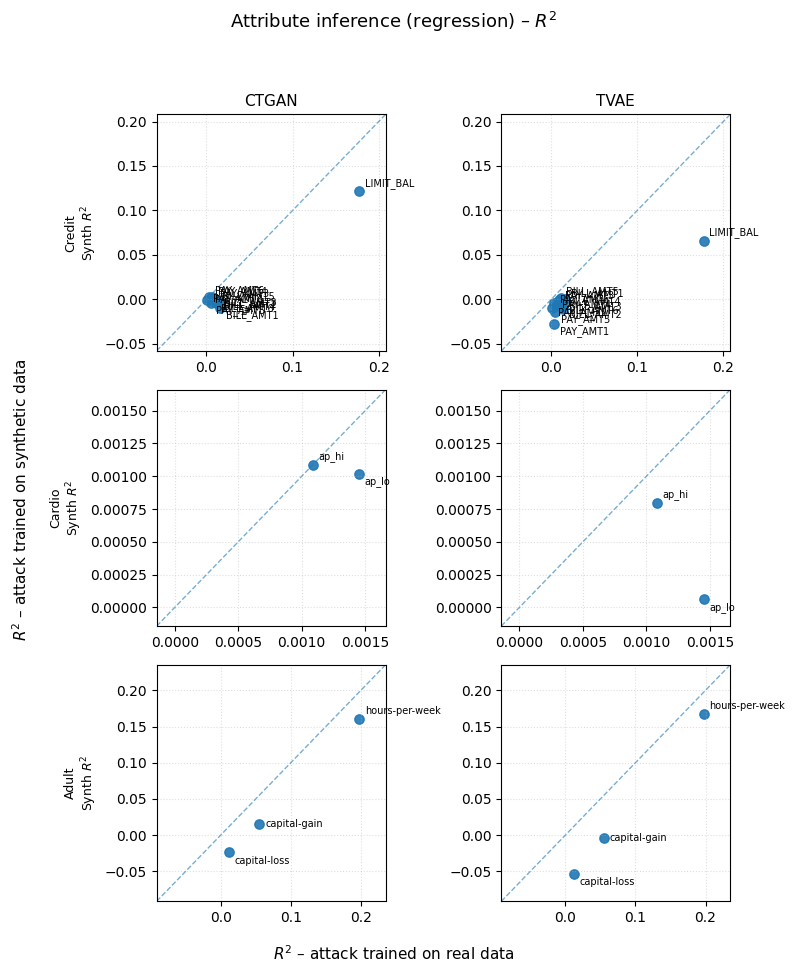

In [41]:
# Regression-risk figure:
fig_r2 = make_attr_reg_grid(attr_reg_long, metric="r2")

## Privacy anonymeter

In [11]:
result_anonym_credit = get_anonymeter_result(dict_results_credit)
result_anonym_adult = get_anonymeter_result(dict_results_adult)
result_anonym_cardio = get_anonymeter_result(dict_results_cardio)

In [12]:
result_anonym = result_anonym_credit | result_anonym_adult | result_anonym_cardio

In [13]:
pretty, runs_long, summary_raw = anonymeter_pretty_tables(result_anonym)
print(pretty.to_string(index=False))

dataset_model dataset model   Uni PR (orig)   Uni PR (ctrl)  Uni PR (naive) Uni SpecificPrivacy Multi PR (orig) Multi PR (ctrl) Multi PR (naive) Multi SpecificPrivacy  Link PR (orig)  Link PR (ctrl) Link PR (naive) Link SpecificPrivacy
  adult CTGAN   adult CTGAN 0.0423 ± 0.0044 0.0374 ± 0.0060 0.0017 ± 0.0004     0.0056 ± 0.0083 0.1794 ± 0.0081 0.1463 ± 0.0113  0.0044 ± 0.0016       0.0386 ± 0.0172 0.0189 ± 0.0036 0.0178 ± 0.0027 0.0039 ± 0.0010      0.0021 ± 0.0032
   adult TVAE   adult  TVAE 0.0464 ± 0.0055 0.0415 ± 0.0063 0.0018 ± 0.0007     0.0065 ± 0.0053 0.2053 ± 0.0060 0.1508 ± 0.0060  0.0042 ± 0.0009       0.0641 ± 0.0078 0.0208 ± 0.0040 0.0158 ± 0.0022 0.0041 ± 0.0014      0.0052 ± 0.0038
 cardio CTGAN  cardio CTGAN 0.0531 ± 0.0024 0.0438 ± 0.0018 0.0038 ± 0.0012     0.0097 ± 0.0040 0.1582 ± 0.0068 0.0981 ± 0.0072  0.0196 ± 0.0031       0.0666 ± 0.0082 0.0034 ± 0.0009 0.0040 ± 0.0010 0.0029 ± 0.0008      0.0003 ± 0.0005
  cardio TVAE  cardio  TVAE 0.0610 ± 0.0030 0.0493 ± 0.0

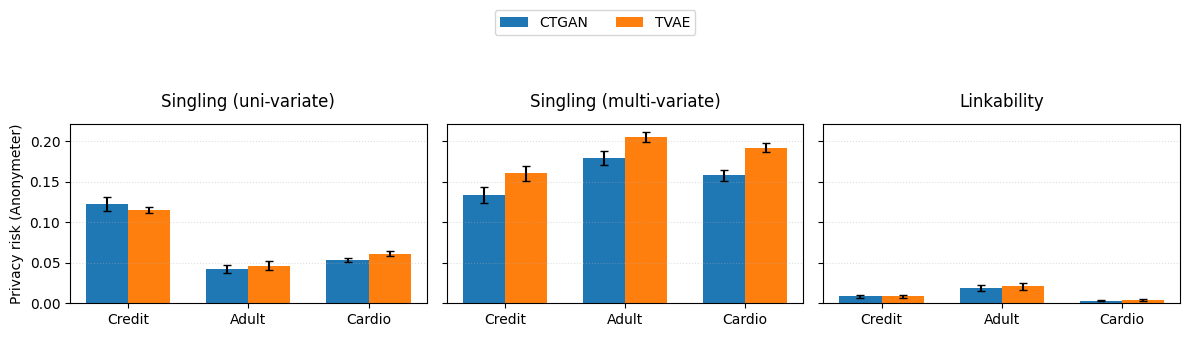

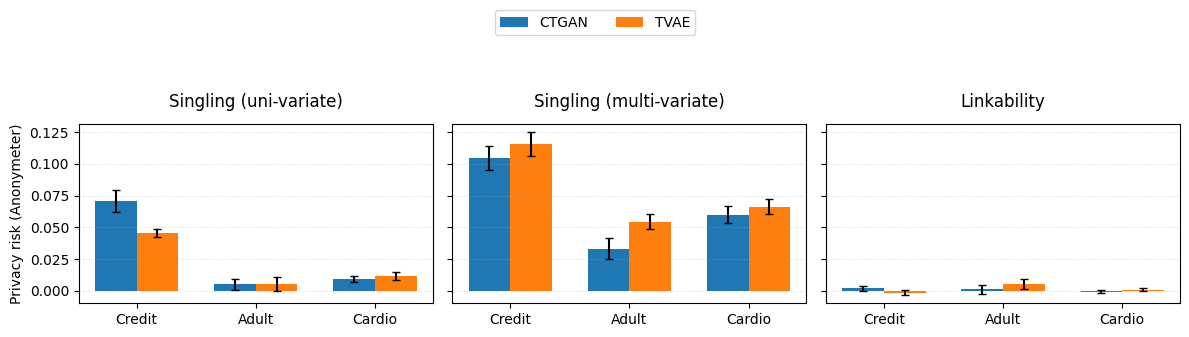

In [14]:
df_anon = build_anonymeter_df(result_anonym)
summary = (
    df_anon
    .groupby(["dataset", "generator", "attack"])
    .agg(
        mean_risk=("privacy_risk_original", "mean"),
        std_risk=("privacy_risk_original", "std"),
        mean_control=("privacy_risk_control", "mean"),
        mean_excess=("excess_risk", "mean"),
        mean_specific=("specific_privacy", "mean"),
    )
    .reset_index()
)

# Use mean_risk (privacy_risk_original) as the main metric
fig_risk = plot_anonymeter_summary(summary, metric="mean_risk")

# If you want to emphasize "extra risk over control":
fig_excess = plot_anonymeter_summary(summary, metric="mean_excess")


In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

real = df_real_adult_train
ctgan = adult_ctgan["generation_results"]['synthetic_data']
tvae = adult_tvae["generation_results"]['synthetic_data']


# Standardize features (important for distance-based methods)
scaler = StandardScaler()
X_real  = scaler.fit_transform(real[num_list_adult])
X_ctgan = scaler.transform(ctgan[num_list_adult])
X_tvae  = scaler.transform(tvae[num_list_adult])

k = 20  # size of local neighborhood
knn = NearestNeighbors(n_neighbors=k)
knn.fit(X_real)

# Distances from each point to its k nearest REAL neighbors
dist_real, _  = knn.kneighbors(X_real)
dist_ctgan, _ = knn.kneighbors(X_ctgan)
dist_tvae, _  = knn.kneighbors(X_tvae)

# Density proxy: inverse of mean distance to neighbors
eps = 1e-8
dens_real  = 1.0 / (dist_real.mean(axis=1)  + eps)
dens_ctgan = 1.0 / (dist_ctgan.mean(axis=1) + eps)
dens_tvae  = 1.0 / (dist_tvae.mean(axis=1)  + eps)

print("Mean local density adult :")
print("  Real :", dens_real.mean())
print("  CTGAN:", dens_ctgan.mean())
print("  TVAE :", dens_tvae.mean())

print("\nVariance of local density adult :")
print("  Real :", dens_real.var())
print("  CTGAN:", dens_ctgan.var())
print("  TVAE :", dens_tvae.var())


Mean local density adult :
  Real : 6.141592768955715
  CTGAN: 4.837146089351664
  TVAE : 4.935835908137321

Variance of local density adult :
  Real : 27.375968500753963
  CTGAN: 18.040534030869576
  TVAE : 18.57362815152039


In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

real = df_real_credit_card_train
ctgan = credit_ctgan["generation_results"]['synthetic_data']
tvae = credit_tvae["generation_results"]['synthetic_data']


# Standardize features (important for distance-based methods)
scaler = StandardScaler()
X_real  = scaler.fit_transform(real[num_list_credit_card])
X_ctgan = scaler.transform(ctgan[num_list_credit_card])
X_tvae  = scaler.transform(tvae[num_list_credit_card])

k = 20  # size of local neighborhood
knn = NearestNeighbors(n_neighbors=k)
knn.fit(X_real)

# Distances from each point to its k nearest REAL neighbors
dist_real, _  = knn.kneighbors(X_real)
dist_ctgan, _ = knn.kneighbors(X_ctgan)
dist_tvae, _  = knn.kneighbors(X_tvae)

# Density proxy: inverse of mean distance to neighbors
eps = 1e-8
dens_real  = 1.0 / (dist_real.mean(axis=1)  + eps)
dens_ctgan = 1.0 / (dist_ctgan.mean(axis=1) + eps)
dens_tvae  = 1.0 / (dist_tvae.mean(axis=1)  + eps)

print("Mean local density credit:")
print("  Real :", dens_real.mean())
print("  CTGAN:", dens_ctgan.mean())
print("  TVAE :", dens_tvae.mean())

print("\nVariance of local density credit:")
print("  Real :", dens_real.var())
print("  CTGAN:", dens_ctgan.var())
print("  TVAE :", dens_tvae.var())


Mean local density credit:
  Real : 3.3254903575053043
  CTGAN: 2.3408907320836905
  TVAE : 2.122035374430374

Variance of local density credit:
  Real : 7.512653696535384
  CTGAN: 4.248422940614155
  TVAE : 2.398266867065753


In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

real = df_real_cardio_train
ctgan = cardio_ctgan["generation_results"]['synthetic_data']
tvae = cardio_tvae["generation_results"]['synthetic_data']


# Standardize features (important for distance-based methods)
scaler = StandardScaler()
X_real  = scaler.fit_transform(real[num_list_cardio])
X_ctgan = scaler.transform(ctgan[num_list_cardio])
X_tvae  = scaler.transform(tvae[num_list_cardio])

k = 20  # size of local neighborhood
knn = NearestNeighbors(n_neighbors=k)
knn.fit(X_real)

# Distances from each point to its k nearest REAL neighbors
dist_real, _  = knn.kneighbors(X_real)
dist_ctgan, _ = knn.kneighbors(X_ctgan)
dist_tvae, _  = knn.kneighbors(X_tvae)

# Density proxy: inverse of mean distance to neighbors
eps = 1e-8
dens_real  = 1.0 / (dist_real.mean(axis=1)  + eps)
dens_ctgan = 1.0 / (dist_ctgan.mean(axis=1) + eps)
dens_tvae  = 1.0 / (dist_tvae.mean(axis=1)  + eps)

print("Mean local density cardio :")
print("  Real :", dens_real.mean())
print("  CTGAN:", dens_ctgan.mean())
print("  TVAE :", dens_tvae.mean())

print("\nVariance of local density cardio:")
print("  Real :", dens_real.var())
print("  CTGAN:", dens_ctgan.var())
print("  TVAE :", dens_tvae.var())


Mean local density cardio :
  Real : 7.551533282298709
  CTGAN: 6.20541060002577
  TVAE : 6.2928299804304055

Variance of local density cardio:
  Real : 30.6971382712536
  CTGAN: 6.26360428683318
  TVAE : 6.238012896340937


## Unload Data

In [1]:
!rm -rf ../../pipeline_tabular_data_results/data/**
!GIT_LFS_SKIP_SMUDGE=1 git -C ../../pipeline_tabular_data_results checkout -- data/**

!rm -rf ../../pipeline_tabular_data_results/baseline/**
!GIT_LFS_SKIP_SMUDGE=1 git -C ../../pipeline_tabular_data_results checkout -- baseline/**

!rm -rf ../../pipeline_tabular_data_results/utility_evaluation_pipeline/*baseline*/*
!GIT_LFS_SKIP_SMUDGE=1 git -C ../../pipeline_tabular_data_results checkout -- utility_evaluation_pipeline/*baseline*/*

!rm -rf ../../pipeline_tabular_data_results/privacy_evaluation_pipeline/*baseline*/*
!GIT_LFS_SKIP_SMUDGE=1 git -C ../../pipeline_tabular_data_results checkout -- privacy_evaluation_pipeline/*baseline*/*

!git -C ../../pipeline_tabular_data_results lfs prune



prune: 50 local objects, 1534 retained, done.                                   
